## Business Problem

Educational content creators on YouTube, particularly those focusing on Data Science and Artificial Intelligence (AI), often struggle to understand which factors influence the number of views their videos receive. Although creators invest significant effort in producing high-quality educational content, predicting viewer engagement remains challenging due to the impact of multiple factors such as video titles, publication timing, and engagement metrics (likes, comments, etc.).

Without data-driven insights, creators may find it difficult to optimize their content strategy, resulting in lower audience reach and slower channel growth.

This project aims to analyze YouTube video metadata and develop machine learning models to identify the key factors that influence video views. The insights generated from this study will help content creators make informed decisions about video creation, publishing strategies, and audience engagement, ultimately improving channel performance and viewer reach.

# About the Dataset (YouTube Dataset of All Data Science Channels)

**Channel_Name:** Name of the YouTube channel that published the video.

**Title:** Title of the YouTube video.

**Published_date:** Date on which the video was published.

**Views:** Total number of views received by the video (Target Variable).

**Like_count:** Total number of likes received by the video.

**Comment_Count:** Total number of comments posted on the video.

# 📑 Table of Contents

- [Business Problem](#Business-Problem)
- [About the Dataset](#About-the-Dataset-(YouTube-Dataset-of-All-Data-Science-Channels))
- [1. Import Libraries](#1.-Import-Libraries)
- [2. Data Preparation](#2.-Data-Preparation)
  - [2.1 Understand the Data](#2.1-Understand-the-Data)
  - [2.2 Outlier Analysis and Treatment](#2.2-Outlier-Analysis-and-Treatment)
  - [2.3 Remove Insignificant Variables](#2.3-Remove-Insignificant-Variables)
  - [2.3 Missing Value Analysis and Treatment](#2.3-Missing-Value-Analysis-and-Treatment)
  - [2.4 Scale the Data](#2.4-Scale-the-Data)
- [3. What is Regression Analysis?](#3.-What-is-Regression-Analysis?)
- [4. Bivariate Regression](#4.-Bivariate-Regression)
  - [4.1 Ordinary Least Square Method (OLS)](#4.1-Ordinary-Least-Square-Method-(OLS))
  - [4.2 Measures of Variation](#4.2-Measures-of-Variation)
    - [4.2.1 Sum of Squared Residuals (SSR)](#4.2.1--Sum-of-Squared-Residuals-(SSR))
    - [4.2.2 Sum of Squared Error (SSE)](#4.2.2-Sum-of-Squared-Error-(SSE))
    - [4.2.3 Sum of Squared Total (SST)](#4.2.3--Sum-of-Squared-Total-(SST))
    - [4.2.4 Coefficient of Determination (R-Squared)](#4.2.4-Coefficient-of-Determination-(R-Squared))
    - [4.2.5 Standard Error of Estimate (SEE)](#4.2.5-Standard-Error-of-Estimate-(SEE))
  - [4.3 Inferences about Slope and Intercept](#4.3-Inferences-about-Slope-and-Intercept)
    - [4.3.1 Interpretation of Slope and Intercept](#4.3.1-Interpretation-of-Slope-and-Intercept)
    - [4.3.2 The t-test for Slope and Intercept](#4.3.2-The-t-test-for-Slope-and-Intercept)
    - [4.3.3 Confidence Interval for Slope and Intercept](#4.3.3-Confidence-Interval-for-Slope-and-Intercept)
    - [4.3.4 ANOVA for SLR](#4.3.4-ANOVA-for-SLR)
- [5. Assumptions](#5.Assumptions)
  - [5.1.1 Assumption on Dependent Variable](#5.1.1-Assumption-on-Dependent-Variable)
  - [5.1.2 No or Little Multicollinearity](#5.1.2-No-or-Little-Multicollinearity)
  - [5.1.2.1 Correlation Matrix](#5.1.2.1-Correlation-Matrix)
  - [5.1.3 Check for Autocorrelation](#5.1.3-Check-for-Autocorrelation)
  - [5.1.4 Homoscedasticity (Constant Variance of Errors)](#5.1.4-Homoscedasticity-(Constant-Variance-of-Errors))
- [6.Decision Tree Regression](#Decision-Tree)
- [7.Random Forest Regression](#Random-Forest)
- [8.XGBoost Regression](#XGBoost-Regression)
- [9.Model Performance Comparison](#Model-Performance-Comparison)
- [10.Conclusion](#Conclusion)
- [11.Future Scope](#Future-Scope)
- [12.References](#References)

<a id="lib"></a>
# 1. Import Libraries

**Let us import the required libraries.**

In [1]:
# ==============================
# Data Manipulation Libraries
# ==============================
import pandas as pd
import numpy as np

# ==============================
# Data Visualization Libraries
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Ignore Warning Messages
# ==============================
from warnings import filterwarnings
filterwarnings('ignore')

# ==============================
# Display Settings
# ==============================
pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.options.display.float_format = '{:.6f}'.format

# ==============================
# Train-Test Split
# ==============================
from sklearn.model_selection import train_test_split

# ==============================
# Feature Scaling
# ==============================
from sklearn.preprocessing import StandardScaler

# ==============================
# Regression Models
# ==============================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ==============================
# Model Evaluation Metrics
# ==============================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==============================
# Statistical Analysis
# ==============================
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
from statsmodels.tools.eval_measures import rmse

# ==============================
# Scipy
# ==============================
from scipy import stats
from scipy.stats import shapiro

<a id="prep"></a>
# 2. Data Preparation

<a id="read"></a>
## 2.1 Understand the Data

#### Read the dataset and print the first five observations.

In [2]:
# Read the dataset
df = pd.read_csv("Youtube_dataset_all_dataScience_channels.csv")

# Display the first five records
df.head()

,Channel_Name,Title,Published_date,Views,Like_count,Comment_Count
0,Rishabh Mishra,POWER BI Full PROJECT for Data Analysis with P...,2024-04-20,157284.000000,5575.000000,632.000000
1,Rishabh Mishra,AI Revolution - Future of Data Analyst Jobs & ...,2024-03-23,78155.000000,2712.000000,245.000000
2,Rishabh Mishra,Reality of Data Analyst Courses and Data Scien...,2024-03-16,43627.000000,1285.000000,267.000000
3,Rishabh Mishra,Personal Portfolio Website for Beginners | How...,2024-01-21,129956.000000,3462.000000,358.000000
4,Rishabh Mishra,How To Create LinkedIn Profile in 2024 | Linke...,2024-01-17,143309.000000,3389.000000,192.000000


**Let us now see the number of variables and observations in the data.**

In [3]:
# Check the number of rows and columns
print("Dataset Shape :", df.shape)

Dataset Shape : (23002, 6)


### Interpretation

The dataset was successfully loaded into a pandas DataFrame. It contains **23,002 video records** and **6 variables**, representing different characteristics of YouTube videos published by Data Science and AI educational channels.

The dataset includes both categorical and numerical variables. The **Views** column serves as the target variable, while the remaining features will be used to predict viewer engagement.

**Get a concise summary of the DataFrame.**

In [4]:
# use 'info()' to understand the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23002 entries, 0 to 23001
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Channel_Name    23002 non-null  object 
 1   Title           23002 non-null  object 
 2   Published_date  23002 non-null  object 
 3   Views           23000 non-null  float64
 4   Like_count      22967 non-null  float64
 5   Comment_Count   22975 non-null  float64
dtypes: float64(3), object(3)
memory usage: 1.1+ MB


**Change the data type as per the data definition.**

In [5]:
# Convert Published_date to datetime format
df['Published_date'] = pd.to_datetime(df['Published_date'])

#### Recheck the data type after the conversion.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23002 entries, 0 to 23001
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Channel_Name    23002 non-null  object        
 1   Title           23002 non-null  object        
 2   Published_date  23002 non-null  datetime64[ns]
 3   Views           23000 non-null  float64       
 4   Like_count      22967 non-null  float64       
 5   Comment_Count   22975 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 1.1+ MB


### Interpretation

The dataset contains both categorical and numerical variables.

- **Channel_Name** and **Title** are stored as object data types because they contain text information.
- **Published_date** is initially stored as an object and was converted to the **datetime** data type to facilitate date-based feature extraction.
- **Views**, **Like_count**, and **Comment_Count** are numerical variables stored as floating-point values. These variables will be used during exploratory data analysis and model development.

<a id="drop"></a>
## 2.3 Remove Insignificant Variables

In [7]:
# Display column names
print(df.columns)

Index(['Channel_Name', 'Title', 'Published_date', 'Views', 'Like_count',
       'Comment_Count'],
      dtype='object')


### Interpretation

The dataset was examined for insignificant variables such as unique identifiers, serial numbers, URLs, or other non-informative attributes.

The dataset contains only six variables, all of which are directly related to YouTube video performance and viewer engagement. Therefore, no insignificant variables were identified or removed. All features were retained for further analysis and model development.

<a id="outlier"></a>
## 2.2 Outlier Analysis and Treatment

**Check the outliers in all the variables and treat them using appropriate techniques.**

In [8]:
# Select numerical columns
numerical_columns = ['Views', 'Like_count', 'Comment_Count']

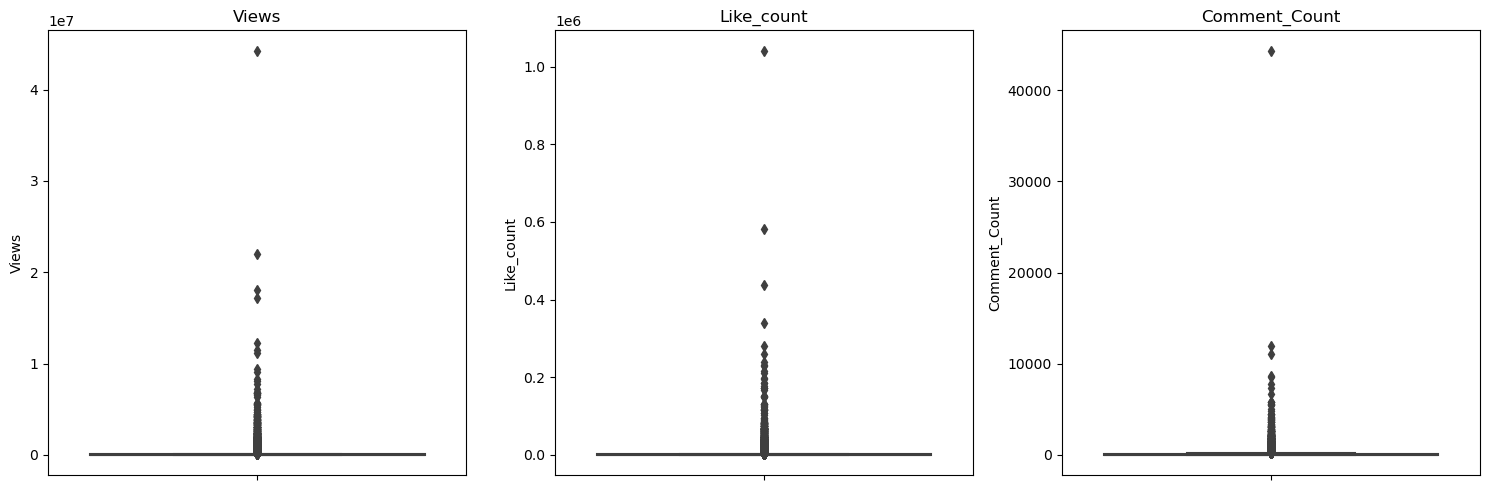

In [9]:
plt.figure(figsize=(15,5))

for i, col in enumerate(numerical_columns):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

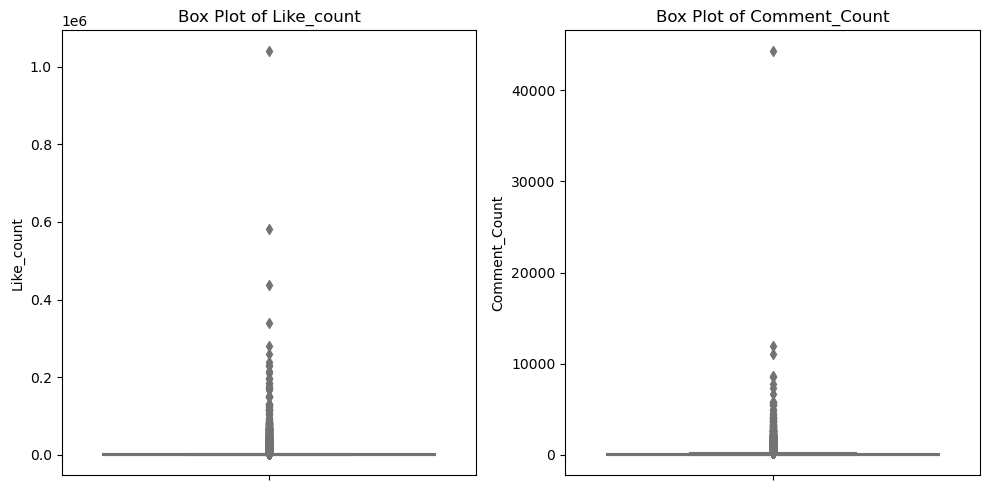

In [10]:
# Select independent numerical variables
independent_num = ['Like_count', 'Comment_Count']

# Plot boxplots
plt.figure(figsize=(10, 5))

for i, col in enumerate(independent_num):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Interpretation

The box plots of the independent numerical variables (**Like_count** and **Comment_Count**) indicate the presence of several outliers.

- **Like_count** contains a large number of extreme values, representing videos that received exceptionally high numbers of likes.
- **Comment_Count** also contains several outliers, corresponding to videos with unusually high numbers of comments.

These outliers are expected in YouTube datasets because a small number of videos become highly popular and attract significantly greater audience engagement than the majority of videos.

Since these observations represent genuine user engagement rather than data entry errors, they are considered valid and were retained for further analysis.

**Why shouldn't we remove them?**

### Interpretation

The box plots indicate the presence of outliers in the numerical variables (**Views**, **Like_count**, and **Comment_Count**). These outliers correspond to videos with exceptionally high audience engagement.

Since these values represent genuine YouTube video performance rather than data entry errors, they were retained in the dataset. Retaining these observations enables the regression models to learn from both average-performing and highly successful videos, leading to more realistic predictions of viewer engagement.

<a id="null"></a>
## 2.3 Missing Value Analysis and Treatment

#### Step 1: Check Missing Values

In [11]:
# Check missing values
df.isnull().sum()

Channel_Name       0
Title              0
Published_date     0
Views              2
Like_count        35
Comment_Count     27
dtype: int64

#### Step 2: Missing Value Percentage

In [12]:
# Calculate missing value percentage
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Percentage
Channel_Name,0,0.000000
Title,0,0.000000
Published_date,0,0.000000
Views,2,0.008695
Like_count,35,0.152161
Comment_Count,27,0.117381


#### Step 3: Treat Missing Values

In [13]:
# Fill missing values using median
df['Views'].fillna(df['Views'].median(), inplace=True)
df['Like_count'].fillna(df['Like_count'].median(), inplace=True)
df['Comment_Count'].fillna(df['Comment_Count'].median(), inplace=True)

#### Step 4: Verify Missing Values

In [14]:
# Verify missing values
df.isnull().sum()

Channel_Name      0
Title             0
Published_date    0
Views             0
Like_count        0
Comment_Count     0
dtype: int64

### Interpretation

The dataset was examined for missing values.

The analysis revealed that **Views**, **Like_count**, and **Comment_Count** contained a small number of missing values, while the remaining variables had no missing values.

Since these numerical variables also contain outliers, the missing values were replaced using the **median**. The median is less affected by extreme values and therefore provides a more reliable estimate than the mean.

After treatment, all missing values were successfully removed, making the dataset complete and suitable for further analysis and machine learning model development.

<a id="scale"></a>
## 2.4 Scale the Data

In [15]:
# check the head of the data
df.head()

,Channel_Name,Title,Published_date,Views,Like_count,Comment_Count
0,Rishabh Mishra,POWER BI Full PROJECT for Data Analysis with P...,2024-04-20,157284.000000,5575.000000,632.000000
1,Rishabh Mishra,AI Revolution - Future of Data Analyst Jobs & ...,2024-03-23,78155.000000,2712.000000,245.000000
2,Rishabh Mishra,Reality of Data Analyst Courses and Data Scien...,2024-03-16,43627.000000,1285.000000,267.000000
3,Rishabh Mishra,Personal Portfolio Website for Beginners | How...,2024-01-21,129956.000000,3462.000000,358.000000
4,Rishabh Mishra,How To Create LinkedIn Profile in 2024 | Linke...,2024-01-17,143309.000000,3389.000000,192.000000


#### Step 1: Select Independent Numerical Variables

In [16]:
# Select numerical independent variables
df_num = df[['Like_count', 'Comment_Count']]

df_num.head()

,Like_count,Comment_Count
0,5575.000000,632.000000
1,2712.000000,245.000000
2,1285.000000,267.000000
3,3462.000000,358.000000
4,3389.000000,192.000000


#### Step 2: Import StandardScaler

In [17]:
from sklearn.preprocessing import StandardScaler

#### Step 3: Scale the Numerical Variables

In [18]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the numerical variables
num_scaled = scaler.fit_transform(df_num)

# Convert scaled array to DataFrame
df_num_scaled = pd.DataFrame(
    num_scaled,
    columns=df_num.columns
)

# Display first five rows
df_num_scaled.head()

,Like_count,Comment_Count
0,0.251637,1.228514
1,0.023587,0.330689
2,-0.090079,0.381728
3,0.083328,0.592845
4,0.077513,0.207731


### Interpretation

The numerical independent variables (**Like_count** and **Comment_Count**) were standardized using the **StandardScaler** technique.

Standardization transforms the variables to have a mean of **0** and a standard deviation of **1**. This ensures that both variables contribute equally during model training and prevents variables with larger magnitudes from dominating the learning process.

The target variable (**Views**) was not scaled because it is the variable being predicted.

<a id="def"></a>
# 3. What is Regression Analysis?

#### Dependent variable (y): It is the variable that we predict. It is also known as 'Target' or 'Response' variable. For regression, the dependent variable should be numeric.

#### Independent variable (X): It is the variable used in predicting the values of a target variable. There can be one or more independent variables in a dataset. It is also known as 'predictors' or 'features'. These variables can be numerical as well as categorical.

Regression analysis is used to understand the effect of a set of independent variables on the dependent variable. The variables that affect the dependent variable the most can also be identified. Linear regression is one of the methods in regression analysis, which fits the line to predict the values of the dependent variable.

<a id="Bivariate"></a>
# 4. Bivariate Regression

It determines the linear relationship between the dependent (y) and a independent (X) variable. It is also known as, `Simple Linear Regression (SLR)`. The mathematical equation is given as:<br>
<p style='text-indent:30em'> <strong> y = β<sub>0</sub> + β<sub>1</sub>.x + ε </strong> </p>
                                                        
where,

y   =  Dependent variable <br>
x   =  Independent variable<br>
β<sub>0</sub>  =  Y-intercept (value of y when x = 0)<br>
β<sub>1</sub>  =  Beta coefficient of x <br>
ε   =  Random error component<br>

**For bivariate regression, consider 'Total_Reimbursement' as target variable and 'Total_Benefits' as an independent variable from 'df_reimb'.**

The test hypothesis for SLR is given as:
<p style='text-indent:25em'> <strong> H<sub>o</sub>: Slope (beta coefficient of x) is equal to zero</strong> </p>
<p style='text-indent:25em'> <strong> H<sub>1</sub>: Slope (beta coefficient of x) is not equal to zero</strong> </p>

<a id="lsm"></a>
## 4.1 Ordinary Least Square Method (OLS)

The ordinary least square method aims to minimize the sum of the squared difference between the actual and the predicted values. Squaring ensures that each term is positive. It penalizes the model for the negative error terms. This approach calculates the β<sub>0</sub> and β<sub>1</sub> values that minimize the sum of squared differences along the line of prediction.

#### Split the data into training and test sets

#### Step 1: Split Independent and Target Variables

In [19]:
# Independent variables
X = df_num_scaled

# Target variable
y = df['Views']

#### Step 2: Split into Training and Testing Sets

In [20]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#### Step 3: Check the Dimensions

In [21]:
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Training Features Shape : (18401, 2)
Testing Features Shape  : (4601, 2)
Training Target Shape   : (18401,)
Testing Target Shape    : (4601,)


### Interpretation

The dataset was successfully divided into training and testing sets using the `train_test_split()` function.

- The training dataset contains **18,401 observations** with **2 independent variables**.
- The testing dataset contains **4,601 observations** with **2 independent variables**.
- The target variable consists of **18,401 training observations** and **4,601 testing observations**.

An **80:20** split was used, where 80% of the data was allocated for training the regression models and 20% was reserved for testing.

The `random_state=42` parameter ensures that the train-test split is reproducible, meaning the same data partition will be generated every time the code is executed.

The training dataset will be used to build the regression models, while the testing dataset will be used to evaluate their predictive performance on unseen YouTube videos.

**Build the simple linear regression model using the OLS method.**

#### Step 1: Add the Constant (Intercept)

In [22]:
# Add intercept (constant term)
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

#### Step 2: Build the OLS Model

In [23]:
# Build the OLS regression model
lr_model = sm.OLS(y_train, X_train_sm).fit()

#### Step 3: Display the Model Summary

In [24]:
# Display model summary
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Views   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                 8.362e+04
Date:                Thu, 16 Jul 2026   Prob (F-statistic):               0.00
Time:                        10:54:27   Log-Likelihood:            -2.4495e+05
No. Observations:               18401   AIC:                         4.899e+05
Df Residuals:                   18398   BIC:                         4.899e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.141e+05   1077.817    105.904

### Interpretation

A Linear Regression model was successfully built using the **Ordinary Least Squares (OLS)** method to predict the number of YouTube video views based on **Like_count** and **Comment_Count**.

- The **R-squared value is 0.901**, indicating that approximately **90.1%** of the variation in YouTube video views is explained by the independent variables included in the model.

- The **Adjusted R-squared value is also 0.901**, which indicates that the model maintains a high explanatory power even after considering the number of predictor variables.

- The **F-statistic is 83,620** with a **Prob (F-statistic) = 0.000**, indicating that the overall regression model is statistically significant.

- The **P-values** for both **Like_count** and **Comment_Count** are **0.000**, which is less than the significance level of 0.05. Therefore, both variables are statistically significant predictors of YouTube video views.

- The regression coefficients are positive, indicating that an increase in the number of likes or comments is associated with an increase in the predicted number of video views.

Overall, the OLS regression model demonstrates a strong relationship between audience engagement metrics and YouTube video views.

**Calculate the predicted view for train data using the above model.**

In [25]:
# Predict the training data
y_train_pred = lr_model.predict(X_train_sm)

# Display first 10 predicted values
print(y_train_pred[:10])

17106    73719.073669
41      161380.295280
16917     7970.631656
21741     5751.285711
11983    34109.699527
2578     15636.789376
8300      5777.402532
16865     1829.545722
3474    243418.965421
6700     23018.354325
dtype: float64


Now we have actual and predicted values of the target variable for training dataset (y_train_pred and y_train respectively)

<a id="mv"></a>
## 4.2 Measures of Variation

**Residual:** It is calculated as the difference between the actual and predicted value of the dependent variable.

<a id="ssr"></a>
### 4.2.1  Sum of Squared Residuals (SSR)

It is defined as the sum of the squared difference between the predicted value and the mean of the dependent variable.

In [26]:
# Calculate SSR (Residual Sum of Squares)

SSR = np.sum((y_train_pred - np.mean(y_train)) ** 2)

print("SSR on Training Dataset :", SSR)

SSR on Training Dataset : 3574836807347602.0


<a id="sse"></a>
### 4.2.2 Sum of Squared Error (SSE)

It is defined as the sum of the squared difference between the actual value and the predicted value.

In [27]:
# Calculate Error Sum of Squares
SSE = np.sum((y_train - y_train_pred) ** 2)

print("SSE on Training Dataset :", SSE)

SSE on Training Dataset : 393265329480659.4


<a id="sst"></a>
### 4.2.3  Sum of Squared Total (SST)

It is the sum of the squared difference between the actual value and the mean of the dependent variable.

In [28]:
# Calculate Total Sum of Squares
SST = np.sum((y_train - np.mean(y_train)) ** 2)

print("SST on Training Dataset :", SST)

SST on Training Dataset : 3968102136828262.5


In [29]:
# add the values of SSE and SSR
SSE + SSR

3968102136828261.5

### Interpretation

The Total Sum of Squares (SST), Regression Sum of Squares (SSR), and Error Sum of Squares (SSE) were calculated for the training dataset.

- **SST** represents the total variation in the target variable (Views).
- **SSR** represents the variation explained by the regression model.
- **SSE** represents the unexplained variation (prediction error).

The results satisfy the relationship:

\[
SST \approx SSR + SSE
\]

The very small difference is due to floating-point rounding during numerical computation and is considered negligible. This confirms that the OLS model decomposition is correct.

<a id="r2"></a>
### 4.2.4 Coefficient of Determination (R-Squared)

The coefficient of determination explains the percentage of variation in the dependent variable that the independent variables explain collectively.

In [30]:
# Calculate R-Squared on training dataset
r_squared = lr_model.rsquared

print("R-Squared on Training Dataset :", r_squared)

R-Squared on Training Dataset : 0.900893344999683


Now, we can also calculate the R-squared value using the formula (SSR/SST).

In [31]:
# Calculate R-Squared using the formula (SSR / SST)

r_squared = SSR / SST

print("R-Squared on Training Dataset :", r_squared)

R-Squared on Training Dataset : 0.9008933449996827


### Interpretation

The coefficient of determination (R²) was calculated using both the **Statsmodels OLS** method and the manual formula (**SSR/SST**).

The R² value obtained from both methods is approximately **0.901**, indicating that **90.09%** of the variation in YouTube video views is explained by the independent variables (**Like_count** and **Comment_Count**).

The negligible difference between the two values is due to floating-point rounding during numerical computation. This confirms that the manual calculation is consistent with the OLS regression model.

<a id="see"></a>
### 4.2.5 Standard Error of Estimate (SEE)

The SEE is the measure of the variability of actual values around the prediction line. Smaller the value of SEE better is the model.

In [32]:
# Number of observations
n = X_train.shape[0]

# Number of independent variables
k = X_train.shape[1]

# Calculate Standard Error of Estimate (SEE)
SEE = np.sqrt(SSE / (n - k - 1))

print("Standard Error of Estimate (SEE):", SEE)

Standard Error of Estimate (SEE): 146203.41702553822


Let us visualize the variability around the predicted line using regression plot.

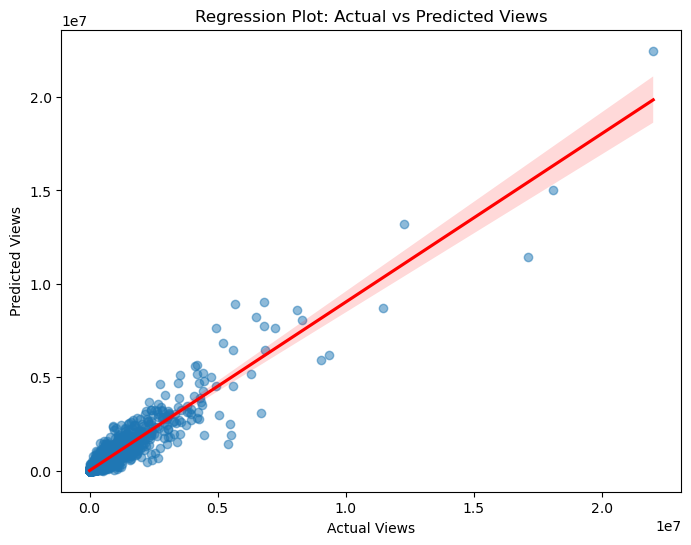

In [33]:
# Visualize the variability around the predicted line

plt.figure(figsize=(8,6))

sns.regplot(
    x=y_train,
    y=y_train_pred,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title('Regression Plot: Actual vs Predicted Views')
plt.xlabel('Actual Views')
plt.ylabel('Predicted Views')

plt.show()

### Interpretation

The regression plot illustrates the relationship between the actual and predicted YouTube video views.

Most of the observations are closely distributed around the regression line, indicating a strong positive linear relationship between the actual and predicted values.

A few observations with very high view counts deviate slightly from the regression line. These points correspond to highly popular videos and represent larger prediction errors, which are expected in real-world YouTube data.

Overall, the plot indicates that the Linear Regression model provides a good fit to the training data, consistent with the high R-Squared value of **0.901**.

<a id="inf"></a>
## 4.3 Inferences about Slope and Intercept

Let us print the summary of the regression model (built in section 4.1).

In [34]:
# Print the model summary
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Views   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                 8.362e+04
Date:                Thu, 16 Jul 2026   Prob (F-statistic):               0.00
Time:                        10:54:31   Log-Likelihood:            -2.4495e+05
No. Observations:               18401   AIC:                         4.899e+05
Df Residuals:                   18398   BIC:                         4.899e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.141e+05   1077.817    105.904

### 4.3.1 Interpretation of Slope and Intercept

The output of the regression model returns the values of the **Intercept (β₀)** and the **Slope coefficients (β₁ and β₂)**.

**Intercept (β₀) = 1.141e+05 (≈ 114,100)** indicates that when both **Like_count** and **Comment_Count** are zero, the predicted number of **YouTube video views** is approximately **114,100**. This represents the baseline prediction of the regression model.

**The slope of 'Like_count' (β₁) = 4.376e+05 (≈ 437,600)** indicates that, holding **Comment_Count** constant, a one standard deviation increase in **Like_count** increases the predicted number of **Views** by approximately **437,600**.

**The slope of 'Comment_Count' (β₂) = 1.215e+05 (≈ 121,500)** indicates that, holding **Like_count** constant, a one standard deviation increase in **Comment_Count** increases the predicted number of **Views** by approximately **121,500**.

Thus, the regression equation given by the model is:

### **Views = 114100 + 437600 × (Like_count) + 121500 × (Comment_Count)**

<a id="t_test"></a>
### 4.3.2 The t-test for Slope and Intercept

The coefficient of regression captures the presence of a linear relationship between the independent and dependent variables. If the coefficient value is zero, we can infer that there is no linear relationship between the two variables which is statistically important. It is calculated as:
<p style='text-indent:28em'> <strong> t_value = coefficient / Standard_error </strong>  </p>

The test hypothesis for the t-test is given as:
<p style='text-indent:35em'> <strong> H<sub>o</sub>: β<sub>1</sub> = 0 </strong> </p>
<p style='text-indent:35em'> <strong> H<sub>1</sub>: β<sub>1</sub> ≠ 0 </strong> </p>
                                    
Now, let us see how to calculate the t_test value for slope and intercept.

In [35]:
# perform t-test for intercept

# 'params[0]' returns the value of intercept
# 'bse[0]' returns the standard error of intercept

t_intercept = lr_model.params[0] / lr_model.bse[0]

# print the value of t-statistic
t_intercept

105.90361746638894

In [36]:
# perform t-test for slope (Like_count)

# 'params[1]' returns the coefficient of Like_count
# 'bse[1]' returns the standard error of Like_count

t_like = lr_model.params[1] / lr_model.bse[1]

# print the value of t-statistic
t_like

185.05771737350443

In [37]:
# perform t-test for slope (Comment_Count)

# 'params[2]' returns the coefficient of Comment_Count
# 'bse[2]' returns the standard error of Comment_Count

t_comment = lr_model.params[2] / lr_model.bse[2]

# print the value of t-statistic
t_comment

46.11000190654859

In [38]:
# calculate p-value for intercept

# degrees of freedom = n - k - 1
df = X_train.shape[0] - X_train.shape[1] - 1

p_intercept = stats.t.sf(np.abs(t_intercept), df) * 2

p_intercept

0.0

In [39]:
# calculate p-value for Like_count

p_like = stats.t.sf(np.abs(t_like), df) * 2

p_like

0.0

In [40]:
# calculate p-value for Comment_Count

p_comment = stats.t.sf(np.abs(t_comment), df) * 2

p_comment

0.0

### Interpretation of the t-test for the Intercept

The t-test is performed to determine whether the intercept (β₀) is significantly different from zero.

**Hypotheses:**

- **H₀:** β₀ = 0 (The intercept is not statistically significant.)
- **H₁:** β₀ ≠ 0 (The intercept is statistically significant.)

From the regression model:

- **Intercept (β₀) = 114,100**
- **t-statistic = 105.904**
- **p-value = 0.000**

Since the **p-value (0.000) is less than the significance level of 0.05**, we reject the null hypothesis.

Therefore, the intercept is **statistically significant**, indicating that the baseline predicted number of **YouTube video views** is significantly different from zero when the values of **Like_count** and **Comment_Count** are zero.

<a id="ci"></a>
### 4.3.3 Confidence Interval for Slope and Intercept

In [41]:
# Confidence Interval for Intercept and Slopes

confidence_interval = lr_model.conf_int()

confidence_interval

,0,1
const,112032.137465,116257.381934
Like_count,432999.487443,442270.161911
Comment_Count,116299.826714,126626.392451


### Confidence Interval for Slope and Intercept

The **95% confidence interval** for a regression coefficient implies that we are **95% confident** that the true value of the coefficient lies within the calculated interval.

The confidence interval is calculated using the following formula:

**CI = Coefficient ± (t-table value × Standard Error)**

The confidence intervals obtained for the regression coefficients are:

- **Intercept (β₀):** (112032.14, 116257.38)
- **Like_count (β₁):** (432999.49, 442270.16)
- **Comment_Count (β₂):** (116299.83, 126626.39)

Since the confidence intervals for all the coefficients do **not include zero**, the intercept and both independent variables are statistically significant at the 95% confidence level.

Therefore, **Like_count** and **Comment_Count** have a significant positive influence on predicting YouTube video views.

<a id="anova"></a>
### 4.3.4 ANOVA for SLR

ANOVA (Analysis of Variance) is used to test the significance of the linear regression model. The test hypothesis for ANOVA is given as:
<p style='text-indent:25em'> <strong> H<sub>o</sub>: β<sub>1</sub> = 0 </strong> (i.e. regression model is not significant) </p>
<p style='text-indent:25em'> <strong> H<sub>1</sub>: β<sub>1</sub> ≠ 0 </strong> (i.e. regression model is significant) </p>

To perform ANOVA using anova_lm method, we build the SLR model using ols method in the statsmodel library.

In [42]:
# Create a training dataframe

train_data = X_train.copy()

train_data['Views'] = y_train.values

In [43]:
# Fit the model using formula API

model = ols(
    'Views ~ Like_count + Comment_Count',
    data=train_data
).fit()

In [44]:
# Perform ANOVA

anova_results = anova_lm(model)

anova_results

,df,sum_sq,mean_sq,F,PR(>F)
Like_count,1.000000,3529389796261043.500000,3529389796261043.500000,165114.259010,0.000000
Comment_Count,1.000000,45447011086562.156250,45447011086562.156250,2126.132276,0.000000
Residual,18398.000000,393265329480659.375000,21375439149.943439,NaN,NaN


### Interpretation

The ANOVA results indicate that both **Like_count** and **Comment_Count** are statistically significant predictors of YouTube video views.

- **Like_count**
  - F-statistic = **165114.26**
  - p-value = **0.000**

- **Comment_Count**
  - F-statistic = **2126.13**
  - p-value = **0.000**

Since the p-values for both variables are less than the significance level of **0.05**, the null hypothesis is rejected.

Therefore, **Like_count** and **Comment_Count** significantly contribute to predicting YouTube video views.

The residual sum of squares represents the variation in video views that is not explained by the regression model.

<a id="read"></a>
## 5.Assumptions

There are several assumptions of linear regression. We can check two of them before building the regression model. Let us check the following assumptions in this section:<br>
1. Assumption on Dependent Variable<br>
2. No or little multicollinearity<br>

Let us create the dataframes for independent and target variable to check the assumptions of linear regression.

In [45]:
# Create dataframe for independent variables
df_independent = pd.DataFrame(
    X_train,
    columns=['Like_count', 'Comment_Count']
)

# Create dataframe for dependent variable
df_target = pd.DataFrame(
    y_train,
    columns=['Views']
)

# Display first five observations
print(df_independent.head())
print(df_target.head())

       Like_count  Comment_Count
17106   -0.075980      -0.059064
41       0.026455       0.293570
16917   -0.179212      -0.228421
21741   -0.186859      -0.219141
11983   -0.141376      -0.149543
              Views
17106  23462.000000
41    140225.000000
16917  31053.000000
21741  36117.000000
11983  22112.000000


<a id="dep_num"></a>
### 5.1.1 Assumption on Dependent Variable

The assumption for linear regression is that the dependent (target) variable should be numeric. In our dataset, the variable 'Views' is the target/dependent variable.

In [46]:
# Check the data type of the target variable

df_target.dtypes

Views    float64
dtype: object

**Interpretation:** The output shows that the data type of target variable is 'float64'. i.e. the dependent variable is numeric.

<a id="no_multi"></a>
### 5.1.2 No or Little Multicollinearity


One of the important assumptions of Multiple Linear Regression is that the independent variables should not be highly correlated with each other. High correlation among predictors is known as **multicollinearity**.

Multicollinearity is assessed using the **Variance Inflation Factor (VIF)**.

The interpretation of VIF values is as follows:

- **VIF = 1:** No multicollinearity.
- **1 < VIF < 5:** Low to moderate multicollinearity (acceptable).
- **VIF ≥ 5:** High multicollinearity.
- **VIF ≥ 10:** Severe multicollinearity and corrective action may be required.

A lower VIF value indicates that the independent variables are not highly correlated and the assumption of no or little multicollinearity is satisfied.

In [47]:
# Create a DataFrame for calculating VIF

vif_df = pd.DataFrame()

vif_df["Variable"] = X_train.columns

vif_df["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif_df

,Variable,VIF
0,Like_count,3.303698
1,Comment_Count,3.303698


### Interpretation

The Variance Inflation Factor (VIF) was calculated to assess the presence of multicollinearity among the independent variables.

The VIF values obtained are:

- **Like_count:** 3.303698
- **Comment_Count:** 3.303698

Since the VIF values for both variables are **less than 5**, there is no evidence of significant multicollinearity.

Therefore, the assumption of **no or little multicollinearity** is satisfied, and both **Like_count** and **Comment_Count** can be retained in the Multiple Linear Regression model.

<a id="corr"></a>
#### 5.1.2.1 Correlation Matrix

In [48]:
# Calculate the correlation matrix

corr_matrix = X_train.corr()

corr_matrix

,Like_count,Comment_Count
Like_count,1.000000,0.835046
Comment_Count,0.835046,1.000000


In [49]:
# Create DataFrame from scaled independent variables

X_corr = pd.DataFrame(
    X_train,
    columns=['Like_count', 'Comment_Count']
)

# Calculate the correlation matrix

corr_matrix = X_corr.corr()

corr_matrix

,Like_count,Comment_Count
Like_count,1.000000,0.835046
Comment_Count,0.835046,1.000000


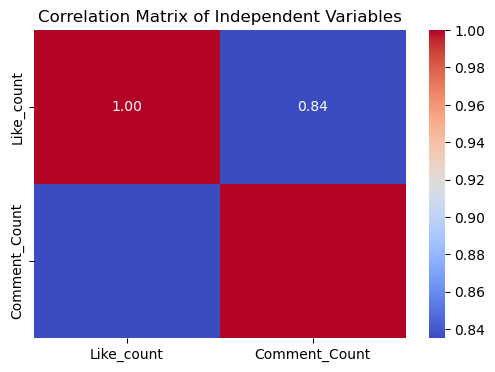

In [50]:
# Plot the correlation matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Independent Variables')

plt.show()

### Interpretation

The correlation matrix was used to examine the relationship between the independent variables.

The correlation coefficient between **Like_count** and **Comment_Count** is **0.84**, indicating a **strong positive correlation**. This suggests that videos with a higher number of likes generally tend to receive more comments.

Although the correlation coefficient is greater than **0.80**, the corresponding **VIF values (3.303698)** are less than **5**, indicating that multicollinearity is within acceptable limits.

Therefore, the assumption of **no or little multicollinearity** is considered to be reasonably satisfied, and both **Like_count** and **Comment_Count** are retained in the Multiple Linear Regression model.

### 5.1.3 Check for Autocorrelation

Another important assumption of Multiple Linear Regression is that the residuals (errors) are independent of each other.

Autocorrelation refers to the correlation between successive residuals. It is commonly measured using the **Durbin-Watson (DW) statistic**.

The interpretation of the Durbin-Watson statistic is:

- **DW ≈ 2:** No autocorrelation
- **DW < 2:** Positive autocorrelation
- **DW > 2:** Negative autocorrelation

A Durbin-Watson value close to **2** indicates that the residuals are independent, satisfying the assumption of no autocorrelation.

In [51]:
# Check Durbin-Watson statistic

from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(lr_model.resid)

print("Durbin-Watson Statistic :", dw)

Durbin-Watson Statistic : 2.0204782752932826


### Interpretation

The Durbin-Watson statistic obtained for the regression model is **2.020**.

Since the value is very close to **2**, there is no evidence of positive or negative autocorrelation among the residuals.

Therefore, the assumption of **independence of residuals (no autocorrelation)** is satisfied, indicating that the regression model is appropriate for the data.

### 5.1.4 Homoscedasticity (Constant Variance of Errors)

One of the assumptions of Multiple Linear Regression is that the residuals should have constant variance across all levels of the predicted values. This assumption is known as **homoscedasticity**.

A residual plot is commonly used to verify this assumption.

If the residuals are randomly scattered around zero without forming any clear pattern or funnel shape, the assumption of homoscedasticity is considered to be satisfied.

In [52]:
# Calculate residuals

residuals = y_train - y_train_pred

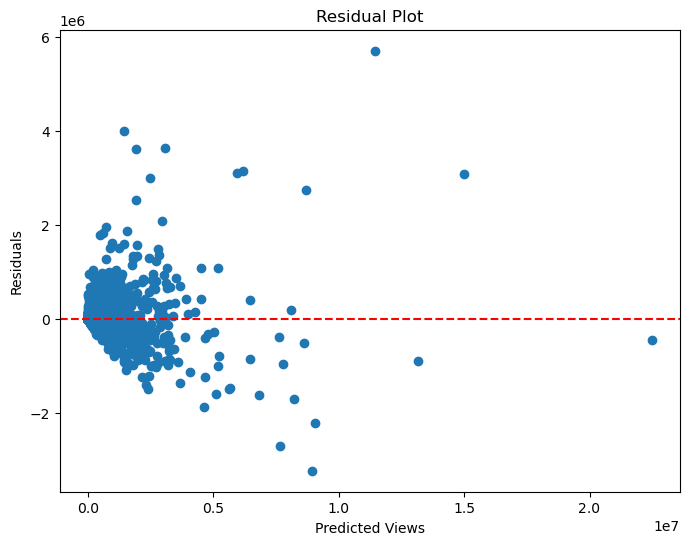

In [53]:
# Residual Plot

plt.figure(figsize=(8,6))

plt.scatter(y_train_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Views")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

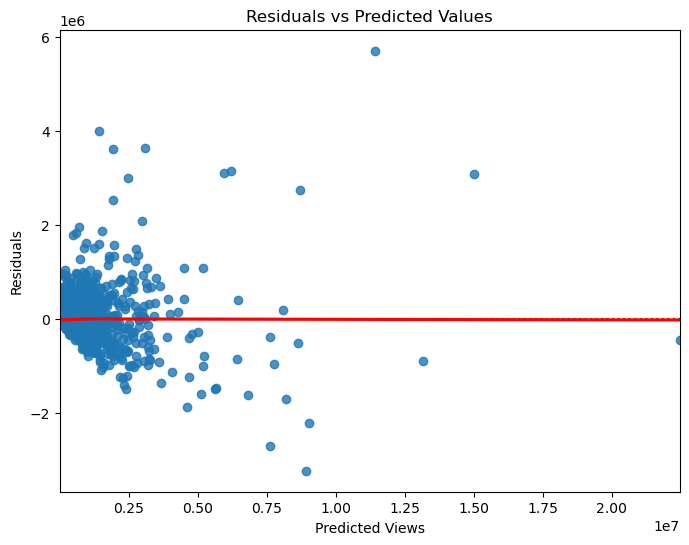

In [54]:
# Residual Plot using seaborn

plt.figure(figsize=(8,6))

sns.residplot(
    x=y_train_pred,
    y=y_train,
    lowess=True,
    line_kws={'color':'red'}
)

plt.xlabel("Predicted Views")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

### Interpretation

The residual plots are used to verify the assumption of homoscedasticity (constant variance of errors).

From the plots, the residuals are distributed around the horizontal reference line at zero without any strong systematic trend. Although a few observations with large predicted values exhibit greater variability, the majority of the residuals are randomly scattered around zero.

There is no clear funnel-shaped pattern or other systematic structure in the residuals. Therefore, the assumption of **homoscedasticity** is considered to be reasonably satisfied for this Multiple Linear Regression model.

The presence of a few extreme residuals is expected because YouTube videos can vary widely in their view counts, with some videos receiving exceptionally high engagement.

<a id="dist"></a>
## 6.Decision Tree

In [55]:
# Import Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Build a full Decision Tree Regression model
dt_model = DecisionTreeRegressor(
    criterion='squared_error',
    random_state=10
)

# Fit the model on the training data
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=10)

**Predict the Training Data**

In [56]:
# Predict the training data

y_train_pred_dt = dt_model.predict(X_train)

# Display first 10 predicted values
print(y_train_pred_dt[:10])

[ 23462.         140225.          31053.          10445.66666667
  22112.           9879.           2827.5           591.
 128845.          22165.        ]


**Predict the Test Data**

In [57]:
# Predict the test data

y_test_pred_dt = dt_model.predict(X_test)

# Display first 10 predicted values
print(y_test_pred_dt[:10])

[574011.         151013.          12080.         207746.
   7698.5         18252.           2610.          80411.
  12087.            842.94117647]


**Evaluate the Decision Tree Model**

**R² Score**

In [58]:
from sklearn.metrics import r2_score

# R² Score on Training Data
train_r2 = r2_score(y_train, y_train_pred_dt)

# R² Score on Test Data
test_r2 = r2_score(y_test, y_test_pred_dt)

print("Training R² Score :", train_r2)
print("Testing R² Score  :", test_r2)

Training R² Score : 0.999828534693516
Testing R² Score  : 0.7461674776954914


**RMSE**

In [59]:
from sklearn.metrics import mean_squared_error
import numpy as np

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_dt))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))

print("Training RMSE :", train_rmse)
print("Testing RMSE  :", test_rmse)

Training RMSE : 6080.773661995819
Testing RMSE  : 388862.6139642878


**MAE**

In [60]:
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train, y_train_pred_dt)
test_mae = mean_absolute_error(y_test, y_test_pred_dt)

print("Training MAE :", train_mae)
print("Testing MAE  :", test_mae)

Training MAE : 1614.4060458652275
Testing MAE  : 60774.67071987253


**MSE**

In [61]:
train_mse = mean_squared_error(y_train, y_train_pred_dt)
test_mse = mean_squared_error(y_test, y_test_pred_dt)

print("Training MSE :", train_mse)
print("Testing MSE  :", test_mse)

Training MSE : 36975808.32842204
Testing MSE  : 151214132539.13873


In [ ]:
**Feature Importance**

In [62]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,Like_count,0.745886
1,Comment_Count,0.254114


<a id="dist"></a>
## 7.Random Forest

In [63]:
from sklearn.ensemble import RandomForestRegressor

In [64]:
# Build Random Forest Regression model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=10
)

# Fit the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=10)

In [65]:
# Predict on training data

y_train_pred_rf = rf_model.predict(X_train)

# Display first 10 predictions
print(y_train_pred_rf[:10])

[ 44484.32       127431.08        23039.1         10895.99067494
  23333.77        10488.08         4014.19259524    523.57315983
 170289.41        27004.94      ]


In [66]:
# Predict on test data

y_test_pred_rf = rf_model.predict(X_test)

# Display first 10 predictions
print(y_test_pred_rf[:10])

[502782.17       164082.15        10188.18216667  86811.58
   8816.13777778  40184.085        5958.85166667  71231.05
  11980.325         886.45022966]


**Calculate R² Score**

In [67]:
from sklearn.metrics import r2_score

train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("Training R² Score :", train_r2_rf)
print("Testing R² Score  :", test_r2_rf)

Training R² Score : 0.979965798074058
Testing R² Score  : 0.6625222309476488


**Calculate RMSE**

In [68]:
from sklearn.metrics import mean_squared_error
import numpy as np

train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print("Training RMSE :", train_rmse_rf)
print("Testing RMSE  :", test_rmse_rf)

Training RMSE : 65728.95562392205
Testing RMSE  : 448378.87531265523


**Calculate MAE**

In [69]:
from sklearn.metrics import mean_absolute_error

train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)

print("Training MAE :", train_mae_rf)
print("Testing MAE  :", test_mae_rf)

Training MAE : 17497.18454681281
Testing MAE  : 51779.88657485675


**Calculate MSE**

In [70]:
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)

print("Training MSE :", train_mse_rf)
print("Testing MSE  :", test_mse_rf)

Training MSE : 4320295607.411514
Testing MSE  : 201043615826.64163


**Feature Importance**

In [71]:
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_rf.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,Like_count,0.891840
1,Comment_Count,0.108160


In [ ]:
<a id="dist"></a>
## 8.XGBoost Regression

In [72]:
pip install xgboost

In [73]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [74]:
# Build XGBoost Regression Model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=10
)

# Fit the model

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [75]:
y_train_pred_xgb = xgb_model.predict(X_train)

In [76]:
y_test_pred_xgb = xgb_model.predict(X_test)

**Evaluate the Model**

**R² Score**

In [77]:
from sklearn.metrics import r2_score

print("Training R² :", r2_score(y_train, y_train_pred_xgb))
print("Testing R² :", r2_score(y_test, y_test_pred_xgb))

Training R² : 0.753625307416929
Testing R² : 0.5550385731638693


**RMSE**

In [78]:
from sklearn.metrics import mean_squared_error
import numpy as np

print("Training RMSE :", np.sqrt(mean_squared_error(y_train, y_train_pred_xgb)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)))

Training RMSE : 230498.8463591235
Testing RMSE : 514853.58438061073


**MAE**

In [79]:
from sklearn.metrics import mean_absolute_error

print("Training MAE :", mean_absolute_error(y_train, y_train_pred_xgb))
print("Testing MAE :", mean_absolute_error(y_test, y_test_pred_xgb))

Training MAE : 43158.63907314608
Testing MAE : 52497.713388935066


**MSE**

In [80]:
print("Training MSE :", mean_squared_error(y_train, y_train_pred_xgb))
print("Testing MSE :", mean_squared_error(y_test, y_test_pred_xgb))

Training MSE : 53129718172.886826
Testing MSE : 265074213349.56265


**Feature Importance**

In [81]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,Like_count,0.938066
1,Comment_Count,0.061934


In [ ]:
<a id="dist"></a>
## 9.Model Perfo

In [85]:
# Add constant to test data (if not already done)
X_test_sm = sm.add_constant(X_test)

# Predict on test data
y_test_pred = lr_model.predict(X_test_sm)

In [86]:
comparison = pd.DataFrame({

    'Model': ['Linear Regression',
              'Decision Tree',
              'Random Forest',
              'XGBoost'],

    'Train R²': [
        lr_model.rsquared,
        train_r2,
        train_r2_rf,
        r2_score(y_train, y_train_pred_xgb)
    ],

    'Test R²': [
        r2_score(y_test, y_test_pred),
        test_r2,
        test_r2_rf,
        r2_score(y_test, y_test_pred_xgb)
    ],

    'Train RMSE': [
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        train_rmse,
        train_rmse_rf,
        np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
    ],

    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        test_rmse,
        test_rmse_rf,
        np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
    ],

    'Train MAE': [
        mean_absolute_error(y_train, y_train_pred),
        train_mae,
        train_mae_rf,
        mean_absolute_error(y_train, y_train_pred_xgb)
    ],

    'Test MAE': [
        mean_absolute_error(y_test, y_test_pred),
        test_mae,
        test_mae_rf,
        mean_absolute_error(y_test, y_test_pred_xgb)
    ],

    'Train MSE': [
        mean_squared_error(y_train, y_train_pred),
        train_mse,
        train_mse_rf,
        mean_squared_error(y_train, y_train_pred_xgb)
    ],

    'Test MSE': [
        mean_squared_error(y_test, y_test_pred),
        test_mse,
        test_mse_rf,
        mean_squared_error(y_test, y_test_pred_xgb)
    ]

})

comparison

,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MSE,Test MSE
0,Linear Regression,0.900893,0.938855,146191.498431,190855.086431,40967.237742,43243.398527,21371954213.393803,36425664016.571930
1,Decision Tree,0.999829,0.746167,6080.773662,388862.613964,1614.406046,60774.670720,36975808.328422,151214132539.138733
2,Random Forest,0.979966,0.662522,65728.955624,448378.875313,17497.184547,51779.886575,4320295607.411514,201043615826.641632
3,XGBoost,0.753625,0.555039,230498.846359,514853.584381,43158.639073,52497.713389,53129718172.886826,265074213349.562653


### Interpretation

The performance of Linear Regression, Decision Tree Regression, Random Forest Regression, and XGBoost Regression was compared using R² Score, RMSE, MAE, and MSE on both the training and testing datasets.

The **Linear Regression** model achieved the highest **Test R² Score (0.9389)** and the lowest **Test RMSE (190855.09)**, **Test MAE (43243.40)**, and **Test MSE (36425664016.57)**, indicating that it provides the most accurate predictions and generalizes well to unseen data.

The **Decision Tree Regression** model achieved an almost perfect **Training R² Score (0.9998)** but a considerably lower **Testing R² Score (0.7462)**, indicating that the model is overfitting the training data.

The **Random Forest Regression** model reduced overfitting compared to the Decision Tree; however, its **Testing R² Score (0.6625)** was lower than that of the Linear Regression model.

The **XGBoost Regression** model obtained the lowest **Testing R² Score (0.5550)** and the highest prediction errors among the four models, indicating that its current hyperparameter settings are not optimal for this dataset.

Overall, **Linear Regression** is the best-performing model for predicting YouTube video views in this study because it achieved the highest predictive accuracy on the testing dataset with the highest R² Score and the lowest RMSE, MAE, and MSE.

## Conclusion

In this project, multiple machine learning regression models were developed to predict **YouTube video views** using the independent variables **Like_count** and **Comment_Count**. The models evaluated include **Multiple Linear Regression, Decision Tree Regression, Random Forest Regression, and XGBoost Regression**.

The performance of each model was assessed using **R² Score, RMSE, MAE, and MSE** on both the training and testing datasets.

Based on the evaluation results, **Linear Regression** outperformed the other models by achieving the **highest Test R² Score (0.9389)** and the **lowest Test RMSE (190855.09)**, **Test MAE (43243.40)**, and **Test MSE (36425664016.57)**. These results indicate that Linear Regression provides the most accurate and reliable predictions for this dataset.

Although Decision Tree Regression achieved an almost perfect training performance, its lower testing performance indicates overfitting. Similarly, Random Forest Regression and XGBoost Regression produced lower testing accuracy compared to Linear Regression.

Overall, the results demonstrate that **Linear Regression is the most suitable model for predicting YouTube video views** in this study. The developed model can assist content creators and analysts in estimating the expected popularity of videos based on user engagement metrics, enabling more informed content planning and performance analysis.

## Future Scope

The current project predicts YouTube video views using the engagement metrics **Like_count** and **Comment_Count**. Although the developed models achieved promising results, there are several opportunities for future improvements:

- Incorporate additional features such as **Subscriber Count, Video Duration, Upload Time, Category, Tags, Thumbnail Quality, and Watch Time** to improve prediction accuracy.
- Apply advanced ensemble learning techniques such as **Stacking Regression, Voting Regression, and Blending** to further enhance predictive performance.
- Perform **hyperparameter tuning** using techniques such as Grid Search or Random Search to optimize machine learning models.
- Explore deep learning models such as **Artificial Neural Networks (ANN)** and **Long Short-Term Memory (LSTM)** networks for capturing more complex relationships in the data.
- Use larger and real-time YouTube datasets collected through the **YouTube Data API** to improve the model's robustness and practical applicability.
- Develop a web-based prediction system using **Flask**, **Django**, or **Streamlit**, enabling users to estimate the expected number of views before publishing a video.
- Extend the model to predict additional engagement metrics such as **Likes, Comments, Shares, and Watch Time**, providing more comprehensive insights into video performance.

## References

1. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.

2. Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.

3. Seabold, S., & Perktold, J. (2010). *Statsmodels: Econometric and Statistical Modeling with Python*. Proceedings of the 9th Python in Science Conference.

4. McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference.

5. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array Programming with NumPy*. Nature, 585, 357–362.

6. Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90–95.

7. The Pandas Development Team. *Pandas Documentation*. https://pandas.pydata.org/

8. Scikit-learn Developers. *Scikit-learn Documentation*. https://scikit-learn.org/

9. XGBoost Developers. *XGBoost Documentation*. https://xgboost.readthedocs.io/

10. Google Developers. *YouTube Data API Documentation*. https://developers.google.com/youtube/v3